In [1]:
'''libraries'''
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#math
import numpy as np

#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c

#Usefull
from tqdm.notebook import tqdm
import os
from scipy.interpolate import interp1d
import pynucastro as pyna
#%matplotlib widget

Read Data from the Snaps


In [2]:
#folder = 'Example_NSM_dyn_ejecta_rosswog_500dias_sin_theoretical_beta_alpha_out\snaps'
folder = 'Example_NSM_dyn_ejecta_rosswog_out_theoretical_500\snaps'

files = os.listdir(folder)

abundances_winnet=[]
time_Winnet=[]
temperature_winnet=[]
density_winnet=[]

for file in tqdm(files):

    abundances_winnet.append(np.loadtxt(os.path.join(folder, file), skiprows=3))
    time_Winnet.append(float(np.loadtxt(os.path.join(folder, file), skiprows=1,max_rows=1, usecols=0)))
    temperature_winnet.append(float(np.loadtxt(os.path.join(folder, file), skiprows=1,max_rows=1, usecols=1)))
    density_winnet.append(float(np.loadtxt(os.path.join(folder, file), skiprows=1,max_rows=1, usecols=2)))

abundances_winnet = np.array(abundances_winnet)
time_Winnet = np.array(time_Winnet) 
density_winnet = np.array(density_winnet)

  0%|          | 0/5721 [00:00<?, ?it/s]

Interpolation to have a smooth Xi curve

In [3]:
initial_time=1 #seconds
final_time=4.32E7 #seconds 500 days= 4.32E7 seconds 100 days= 8.64E7 seconds
N_steps=100000
time = np.exp(np.linspace(np.log(initial_time), np.log(final_time), N_steps))
abundances_time= np.empty((abundances_winnet.shape[1],N_steps))
for i in tqdm(range(abundances_winnet.shape[1])):
    spline_interp = interp1d(time_Winnet, abundances_winnet[:,i,3], kind='linear')
    abundances_time[i] = spline_interp(time)
spline_interp_temp=interp1d(time_Winnet,temperature_winnet,kind='linear')
spline_interp_density=interp1d(time_Winnet,density_winnet,kind='linear')
temperature=spline_interp_temp(time)
density=spline_interp_density(time)

def index_out_win_n_z(n,z):
    idx_start = np.searchsorted(abundances_winnet[0,:,1], z, side='left')
    idx_end = np.searchsorted(abundances_winnet[0,:,1], z, side='right')
    if idx_end>idx_start:
        j=np.searchsorted(abundances_winnet[0,:,0][idx_start:idx_end],n)+idx_start
        if abundances_winnet[0,:,0][j]==n and abundances_winnet[0,:,1][j]==z:
            return j
        else:
            return 'None'
    else:
        return 'None'
    
def abundance_time_of_nuclei_n_z(n,z):

    j=index_out_win_n_z(n,z)
    if j=='None':
        return np.zeros(N_steps)
    elif abundances_winnet[0,:,0][j]==n and abundances_winnet[0,:,1][j]==z:
        return abundances_time[j]
    else:
        return np.zeros(N_steps)
    

  0%|          | 0/6757 [00:00<?, ?it/s]

Rates used in the simulation

In [4]:
rates_Reaclib_winnet=pyna.rates.library.Library(
    libfile=r"Nuclear_data\decays\actual\Reaclib_18_9_20_sin_teoricas_beta_alpha_reaclib1"
    )

# Remove duplicate links from the library
rates_to_remove = []
for pair in rates_Reaclib_winnet.find_duplicate_links():
    for r in pair:
        if isinstance(r, pyna.rates.ReacLibRate):
            rates_to_remove.append(r)
for r in rates_to_remove:
    rates_Reaclib_winnet.remove_rate(r)




filter_alpha=pyna.RateFilter(
    products=['he4'],
    exact=False,
    max_reactants=1,
    max_products=2,
    filter_function=lambda r: r.Q>0 and r.reactants[0].Z==r.products[0].Z+r.products[1].Z)

rates_alpha=rates_Reaclib_winnet.filter(filter_alpha)

filter_beta_minus=pyna.RateFilter(
    max_reactants=1,
    max_products=1,
    filter_function=lambda r: r.Q>0 and r.reactants[0].Z==r.products[0].Z-1)

rates_beta_minus=rates_Reaclib_winnet.filter(filter_beta_minus)

print('number of alpha decays '+str(len(rates_alpha.get_rates()))+', number of beta decays '+str(len(rates_beta_minus.get_rates())))


number of alpha decays 584, number of beta decays 1041


Calcualtion of $\epsilon (t)$

In [5]:

e_b=np.zeros(N_steps)
e_a=np.zeros(N_steps)
e_b_nuclei=[]
e_a_nuclei=[]
nuclei_b=[]
nuclei_a=[]
Xa=np.zeros(N_steps)

y_alpha=np.zeros(len(time_Winnet))
n_alpha=np.zeros(len(time_Winnet))

for beta_rate in tqdm(rates_beta_minus.get_rates()):
    nuclei=beta_rate.reactants[0]
    decay_rate_i=beta_rate.eval(1e7)
    Q_i=beta_rate.Q
    Z_i=nuclei.Z
    N_i=nuclei.N
    m_i=nuclei.dm+(Z_i+N_i)*m_u
    X_i=abundance_time_of_nuclei_n_z(N_i,Z_i)
    e=decay_rate_i*(Q_i*X_i*c**2)/m_i
    e_b+=e
    e_b_nuclei.append(e)
    nuclei_b.append(nuclei)
    

for alpha_rate in tqdm(rates_alpha.get_rates()):
    nuclei=alpha_rate.reactants[0]
    Z_i=nuclei.Z
    N_i=nuclei.N
    if index_out_win_n_z(N_i,Z_i)!='None':
        decay_rate_i=alpha_rate.eval(1e7)
        Q_i=alpha_rate.Q
        m_i=nuclei.dm+(Z_i+N_i)*m_u
        X_i=abundance_time_of_nuclei_n_z(N_i,Z_i)
        e=decay_rate_i*(Q_i*X_i*c**2)/m_i
        e_a+=e
        e_a_nuclei.append(e)
        nuclei_a.append(nuclei)
        if Z_i+N_i>=210:
            Xa+=X_i
        Y_i=abundances_winnet[:, index_out_win_n_z(N_i,Z_i), 2]
        y_alpha+=(decay_rate_i)*Y_i
        n_alpha+=(decay_rate_i)*Y_i*np.exp(-decay_rate_i*time_Winnet)


e_a_erg=e_a*1e4
e_b_erg=e_b*1e4
e_a_nuclei_erg=np.array(e_a_nuclei)*1e4
e_b_nuclei_erg=np.array(e_b_nuclei)*1e4
e_a_nuclei_frac=e_a_nuclei/e_a
e_b_nuclei_frac=e_b_nuclei/e_b

  0%|          | 0/1041 [00:00<?, ?it/s]

  0%|          | 0/584 [00:00<?, ?it/s]

In [6]:
'''find relevant nuclei'''
time_days=time/(24*60*60)
i_initial=np.searchsorted(time_days, 0.1)
i_Final=100000

i_s=np.argsort(-np.max(e_b_nuclei_frac[:,i_initial:i_Final], axis=1))
e_b_nuclei_sorted=[e_b_nuclei_erg[i] for i in i_s]
e_b_nuclei_frac_sorted=[e_b_nuclei_frac[i] for i in i_s]
nuclei_b_sorted=[nuclei_b[i] for i in i_s]

i_s=np.argsort(-np.max(e_a_nuclei_frac[:,i_initial:i_Final], axis=1))
e_a_nuclei_sorted=[e_a_nuclei_erg[i] for i in i_s]
e_a_nuclei_frac_sorted=[e_a_nuclei_frac[i] for i in i_s]    
nuclei_a_sorted=[nuclei_a[i] for i in i_s]

(0.0001, 500)

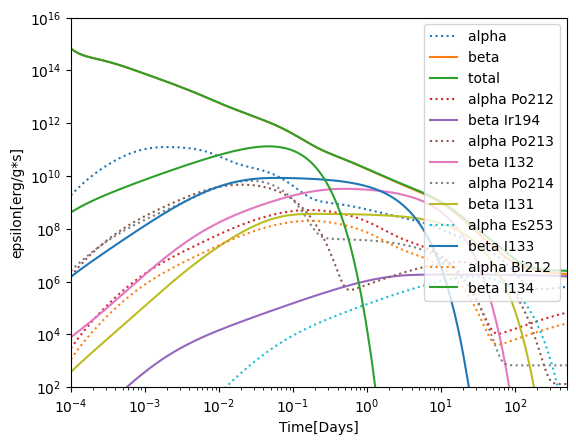

In [7]:
'''Preliminar figures'''
plt.plot(time_days,e_a_erg,label=r'alpha ',linestyle=":")
plt.plot(time_days,e_b_erg,label=r'beta ')
plt.plot(time_days,e_a_erg+e_b_erg,label=r'total ' )
for i in range(5):
    plt.plot(time_days,e_a_nuclei_sorted[i],label=f'alpha {nuclei_a_sorted[i]}',linestyle=":")
    plt.plot(time_days,e_b_nuclei_sorted[i],label=f'beta {nuclei_b_sorted[i]}')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Time[Days]')
plt.ylabel('epsilon[erg/g*s]')
plt.legend()
plt.ylim(1e2,1e16)
plt.xlim(0.0001,500)

In [8]:
#pd.DataFrame({'Epsilon_alpha':e_a_erg,'Time [Days]':time_days}).to_csv('Results/actual_II/alpha/epsilon_alpha.csv',index=False)
#pd.DataFrame({'Epsilon_beta':e_b_erg,'Time [Days]':time_days}).to_csv('Results/actual_II/beta/epsilon_beta.csv',index=False)

In [9]:

#for i in range(20):
#    pd.DataFrame({'time_days':time_days,f'{nuclei_b_sorted[i]} top {i+1}':e_b_nuclei_sorted[i]}).to_csv(f'Results/actual_II/beta/relevants/e_r_{i}.csv',index=False)
#for i in range(20):
#    pd.DataFrame({'time_days':time_days,f'{nuclei_a_sorted[i]} top {i+1}':e_a_nuclei_sorted[i]}).to_csv(f'Results/actual_II/alpha/relevants/e_r_{i}.csv',index=False)
    

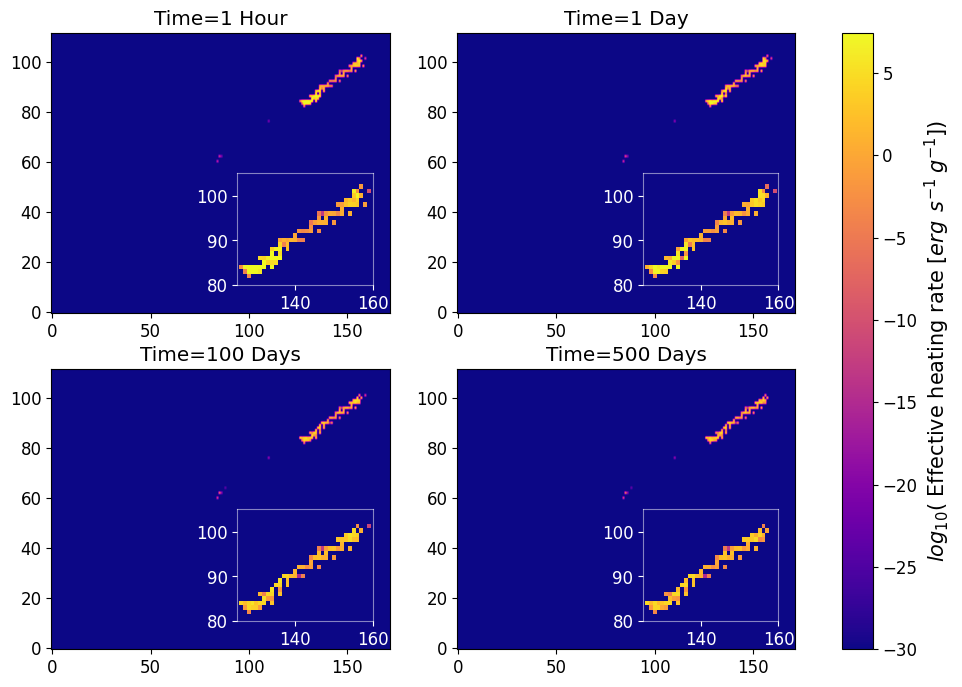

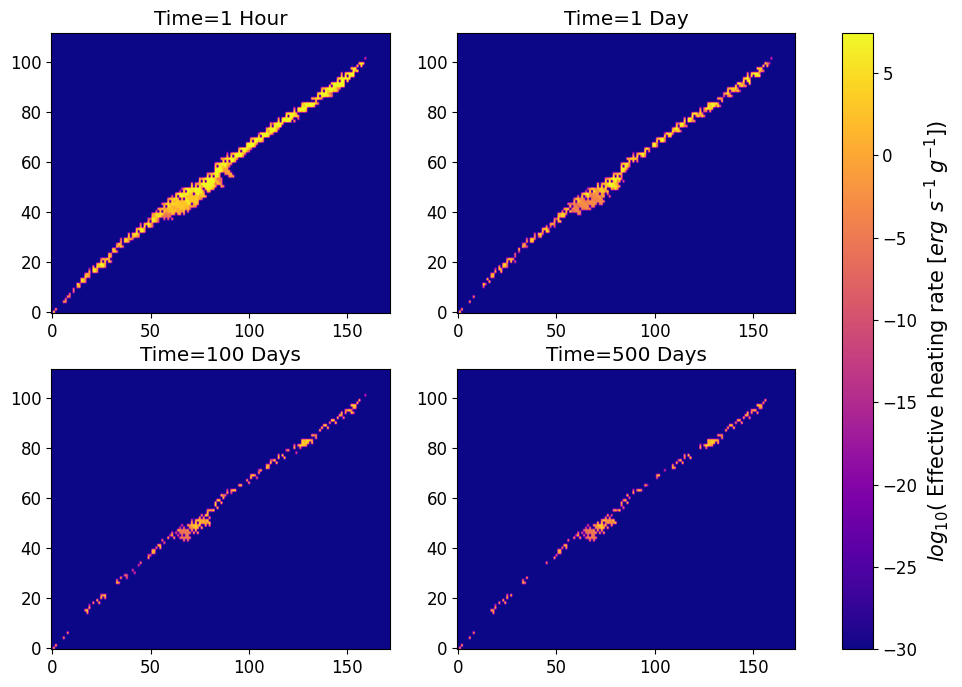

In [10]:
'''Figure 3. nucharts of heating rate'''

max_neutrons = 171
max_protons = 111

def Generar_grafica_epsion_nuchart(tiempo_abundnacia,unit,Decaimiento,x_start,x_end,y_start,y_end):

    heatmap_matrix = np.zeros((max_protons+ 1,max_neutrons + 1))

    if Decaimiento=='Alpha':
        if unit=='Days':
            for i in range(len(nuclei_a)):
                heatmap_matrix[int(nuclei_a[i].Z), int(nuclei_a[i].N)] = e_a_nuclei_erg[i][np.searchsorted(time_days,tiempo_abundnacia,side='left')-1]
        if unit=='Hours':
            for i in range(len(nuclei_a)):
                heatmap_matrix[int(nuclei_a[i].Z), int(nuclei_a[i].N)] = e_a_nuclei_erg[i][np.searchsorted(time/3600,tiempo_abundnacia,side='left')-1]
                
    else:
        if unit=='Days':
            for i in range(len(nuclei_b)):
                heatmap_matrix[int(nuclei_b[i].Z), int(nuclei_b[i].N)] = e_b_nuclei_erg[i][np.searchsorted(time_days,tiempo_abundnacia,side='left')-1]
        if unit=='Hours':
            for i in range(len(nuclei_b)):
                heatmap_matrix[int(nuclei_b[i].Z), int(nuclei_b[i].N)] = e_b_nuclei_erg[i][np.searchsorted(time/3600,tiempo_abundnacia,side='left')-1]

    log_heatmap_matrix = np.log10(heatmap_matrix+1e-30)
    subset=log_heatmap_matrix[y_start:y_end+1,x_start:x_end+1]
    
    return log_heatmap_matrix,subset,tiempo_abundnacia,unit,x_start,x_end,y_start,y_end,heatmap_matrix

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
fig2a, axsa = plt.subplots(2,2, figsize=(12,8),)
t_matrix=[(1,'Hours'),(1,'Days'),(100,'Days'),(500,'Days')]
for i, ax in enumerate(axsa.flat):
    log_heatmap_matrix ,subset, tiempo_abundancia, unidad,x_start,x_end,y_start,y_end,heat_matri1 = Generar_grafica_epsion_nuchart(t_matrix[i][0],t_matrix[i][1],'Alpha',125,160,80,105)
    cax = ax.imshow(log_heatmap_matrix, origin='lower', cmap='plasma', aspect='auto',vmin=-30,vmax=np.log10(5.5**10),extent=[-0.5, max_neutrons+0.5,0-0.5, max_protons+0.5])#
    axins=ax.inset_axes([0.55, 0.1, 0.4, 0.4],xlim=(125,160),ylim=(80,105))
    axins.imshow(subset, origin='lower', cmap='plasma', aspect='auto',vmin=-30,vmax=np.log10(5.5**10),extent=[x_start-0.5, x_end+0.5,y_start-0.5, y_end+0.5])
    for spine in axins.spines.values():
        spine.set_edgecolor('white')
        spine.set_alpha(0.5)
    axins.tick_params(axis='both', colors='white')#,alpha=0.5)
    #ax.indicate_inset_zoom(axins,edgecolor="1")    #ax.set_xlabel("Number of Neutrons")
    #ax.set_ylabel("Number of Protons")
    if unidad=='Days':
        if t_matrix[i][0]==1:
            ax.set_title(f'Time={tiempo_abundancia} Day')
        else:
            ax.set_title(f'Time={tiempo_abundancia} Days')
    if unidad=='Hours':
        if t_matrix[i][0]==1:
            ax.set_title(f'Time={tiempo_abundancia} Hour')
        else:
            ax.set_title(f'Time={tiempo_abundancia} Hours')


plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
fig2b, axsb = plt.subplots(2,2, figsize=(12,8))
t_matrix=[(1,'Hours'),(1,'Days'),(100,'Days'),(500,'Days')]
for i, ax in enumerate(axsb.flat):
    log_heatmap_matrix ,subset, tiempo_abundancia, unidad,x_start,x_end,y_start,y_end,heat_matri  = Generar_grafica_epsion_nuchart(t_matrix[i][0],t_matrix[i][1],'',0,171,0,111)
    cax = ax.imshow(subset, origin='lower', cmap='plasma', aspect='auto',vmin=-30,vmax=np.log10(5.5**10),extent=[x_start-0.5, x_end+0.5,y_start-0.5, y_end+0.5])#
    #ax.set_xlabel("Number of Neutrons")
    #ax.set_ylabel("Number of Protons")
  
    
    if unidad=='Days':
        if t_matrix[i][0]==1:
            ax.set_title(f'Time={tiempo_abundancia} Day')
        else:
            ax.set_title(f'Time={tiempo_abundancia} Days')
    if unidad=='Hours':
        if t_matrix[i][0]==1:
            ax.set_title(f'Time={tiempo_abundancia} Hour')
        else:
            ax.set_title(f'Time={tiempo_abundancia} Hours')
colorbar = fig2a.colorbar(cax, ax=axsa.ravel().tolist(), orientation='vertical')
colorbar.set_label(r'$log_{10}$( Effective heating rate $[erg\:\:s^{-1}\:g^{-1}]$)', fontsize=15)
colorbar = fig2b.colorbar(cax, ax=axsb.ravel().tolist(), orientation='vertical')
colorbar.set_label(r'$log_{10}$( Effective heating rate $[erg\:\:s^{-1}\:g^{-1}]$)', fontsize=15)
fig2a.savefig("figure_epsilon_Approach_II_nucharts_alpha.pdf", bbox_inches="tight")
fig2b.savefig("figure_epsilon_Approach_II_nucharts_beta.pdf", bbox_inches="tight")